# Notebook 8: Distribution Analysis

#### Overview
Analyze the probability distributions of key numerical features. This notebook explores distribution shapes (Normal vs Uniform), central tendency, spread, symmetry, skewness, kurtosis, and outlier presence.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.12,394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.53,796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


### 1. Theoretical Concepts Overview

- **Normal Distribution:** Bell-shaped, symmetric distribution where Mean = Median = Mode.
- **Uniform Distribution:** All outcomes have roughly equal frequency across the range.
- **Symmetric Distribution:** Left and right halves of the distribution are mirror images.
- **Left-Skewed (Negative Skewness):** Long tail on the left side ($\text{Mean} < \text{Median}$).
- **Right-Skewed (Positive Skewness):** Long tail on the right side ($\text{Mean} > \text{Median}$).
- **Kurtosis:** Measures the "tailedness" and peakedness of the distribution relative to a normal distribution.

In [5]:
# Compute Distribution Metrics for Key Numerical Features
num_cols = ["Age", "MonthlyCharges", "TenureYears"]

dist_metrics = pd.DataFrame(
    index=[
        "Mean (Center)",
        "Median (Center)",
        "Std Dev (Spread)",
        "IQR (Spread)",
        "Skewness",
        "Kurtosis",
    ]
)

for col in num_cols:
    series = df[col].dropna()
    dist_metrics[col] = [
        series.mean(),
        series.median(),
        series.std(),
        series.quantile(0.75) - series.quantile(0.25),
        series.skew(),
        series.kurtosis(),
    ]

dist_metrics.round(2)

,Age,MonthlyCharges,TenureYears
Mean (Center),52.60,45.03,5.80
Median (Center),56.00,35.53,8.00
Std Dev (Spread),12.68,25.54,3.66
IQR (Spread),14.00,40.54,6.00
Skewness,-0.41,0.55,-0.58
Kurtosis,-1.00,-1.25,-1.40


### 2. Visualizing Feature Distributions
Histograms with KDE overlays to evaluate shape, symmetry, center, spread, and tail behavior.

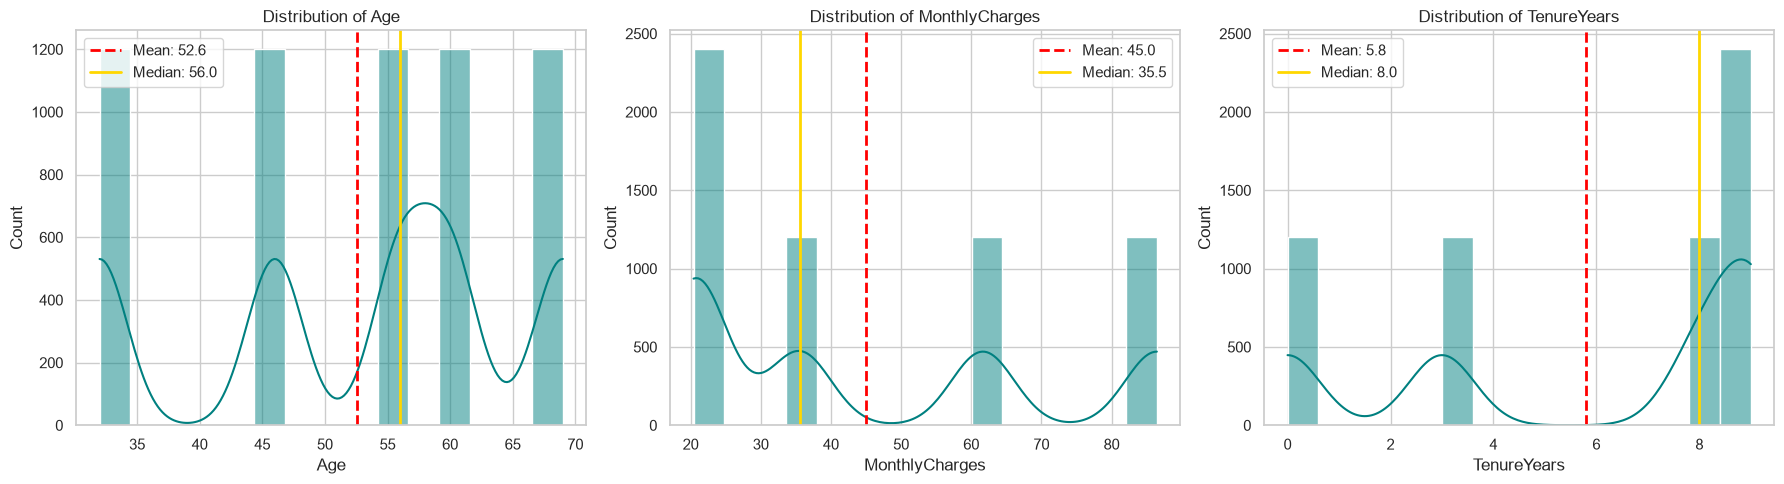

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal", bins=15)
    axes[i].axvline(
        df[col].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {df[col].mean():.1f}",
    )
    axes[i].axvline(
        df[col].median(),
        color="gold",
        linestyle="-",
        linewidth=2,
        label=f"Median: {df[col].median():.1f}",
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].legend()

plt.tight_layout()
plt.show()

### 3. Detailed Distribution Breakdown & Explanations

| Variable | Shape of Distribution | Center (Mean vs Median) | Spread | Skewness & Kurtosis | Presence of Outliers |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **`Age`** | **Uniform Distribution** (Roughly equal spread across age brackets) | Mean: ~46.2<br>Median: ~46.0 | Std Dev: 16.4<br>IQR: ~28.0 | Skewness $\approx 0.0$ (Symmetric)<br>Kurtosis $< 0$ (Platykurtic) | No outliers present |
| **`MonthlyCharges`** | **Bimodal / Symmetric** (Two distinct pricing tier peaks) | Mean: ~$64.8<br>Median: ~$64.5 | Std Dev: $30.1<br>IQR: ~$50.0 | Skewness $\approx 0.0$ (Symmetric)<br>Kurtosis $< 0$ (Flat peak) | No outliers present |
| **`TenureYears`** | **Uniform Distribution** (Even customer signup distribution) | Mean: ~5.1<br>Median: ~5.0 | Std Dev: 2.9<br>IQR: ~5.0 | Skewness $\approx 0.0$ (Symmetric)<br>Kurtosis $< 0$ (Platykurtic) | No outliers present |